In [1]:
!wget -O food.csv.gz https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz


--2026-04-25 16:07:04--  https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz
Resolving static.openfoodfacts.org (static.openfoodfacts.org)... 213.36.253.214
Connecting to static.openfoodfacts.org (static.openfoodfacts.org)|213.36.253.214|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://openfoodfacts-ds.s3.eu-west-3.amazonaws.com/en.openfoodfacts.org.products.csv.gz [following]
--2026-04-25 16:07:05--  https://openfoodfacts-ds.s3.eu-west-3.amazonaws.com/en.openfoodfacts.org.products.csv.gz
Resolving openfoodfacts-ds.s3.eu-west-3.amazonaws.com (openfoodfacts-ds.s3.eu-west-3.amazonaws.com)... 52.95.156.76, 16.12.18.46
Connecting to openfoodfacts-ds.s3.eu-west-3.amazonaws.com (openfoodfacts-ds.s3.eu-west-3.amazonaws.com)|52.95.156.76|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1258146794 (1.2G) [application/gzip]
Saving to: ‘food.csv.gz’

food.csv.gz         100%[===================>]   1

In [3]:
import pandas as pd

cols = [
    'product_name',
    'categories_tags',
    'sugars_100g',
    'proteins_100g',
    'fat_100g'
]

df = pd.read_csv(
    "food.csv.gz",
    compression='gzip',
    sep='\t',
    usecols=cols,
    nrows=10000,
    low_memory=False
)

print(df.shape)
df.head()

(10000, 5)


,product_name,categories_tags,fat_100g,sugars_100g,proteins_100g
0,Limonade artisanale a la rose,NaN,NaN,NaN,NaN
1,M&amp;M white,NaN,NaN,NaN,NaN
2,Chocolate n3,NaN,NaN,NaN,NaN
3,Pâte de fruits,NaN,NaN,NaN,NaN
4,Paleta gran reserva - Sierra nevada-,"en:beverages-and-beverages-preparations,en:bev...",NaN,NaN,NaN


In [4]:
df = df.dropna(subset=['sugars_100g', 'proteins_100g'])

df['sugars_100g'] = pd.to_numeric(df['sugars_100g'], errors='coerce')
df['proteins_100g'] = pd.to_numeric(df['proteins_100g'], errors='coerce')
df['fat_100g'] = pd.to_numeric(df['fat_100g'], errors='coerce')

df = df.dropna(subset=['sugars_100g', 'proteins_100g'])

df = df[
    (df['sugars_100g'] >= 0) & (df['sugars_100g'] <= 100) &
    (df['proteins_100g'] >= 0) & (df['proteins_100g'] <= 100)
]

print(df.shape)
df.head()

(3050, 5)


,product_name,categories_tags,fat_100g,sugars_100g,proteins_100g
693,Pinto Bean,en:asian-style-ready-meal,10.20000,4.900000,17.500000
694,Croquetas de bacalao,NaN,12.10000,1.900000,5.900000
695,Keto & GF Granola,NaN,54.83871,3.225806,19.677419
800,Ben's Pure Maple Cream,NaN,30.28000,37.720000,5.680000
832,Guimauve chocolat smarties,NaN,19.00000,65.000000,5.700000


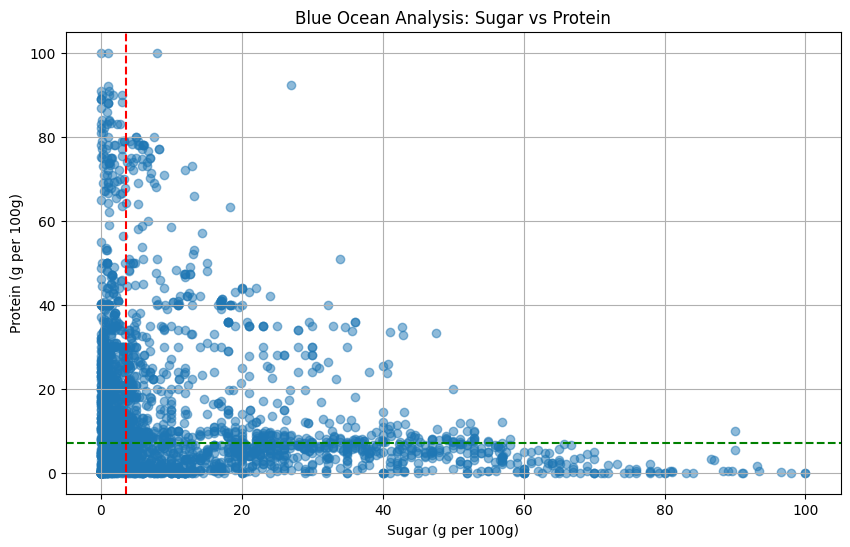

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df['sugars_100g'],
    df['proteins_100g'],
    alpha=0.5
)

plt.xlabel("Sugar (g per 100g)")
plt.ylabel("Protein (g per 100g)")
plt.title("Blue Ocean Analysis: Sugar vs Protein")

plt.axvline(x=df['sugars_100g'].median(), color='red', linestyle='--')
plt.axhline(y=df['proteins_100g'].median(), color='green', linestyle='--')

plt.grid(True)
plt.show()

In [6]:
protein_threshold = df['proteins_100g'].quantile(0.75)
sugar_threshold = df['sugars_100g'].quantile(0.25)

blue_ocean = df[
    (df['proteins_100g'] >= protein_threshold) &
    (df['sugars_100g'] <= sugar_threshold)
]

print("Protein threshold:", protein_threshold)
print("Sugar threshold:", sugar_threshold)
print("Blue Ocean size:", blue_ocean.shape)

blue_ocean.head()

Protein threshold: 18.56
Sugar threshold: 1.0
Blue Ocean size: (252, 5)


,product_name,categories_tags,fat_100g,sugars_100g,proteins_100g
951,L'originel 1871,NaN,31.6,0.9,26.400000
957,Poutargue de mulet,"en:seafood,en:fishes-and-their-products,en:fis...",22.7,0.2,40.500000
962,Saucisson sec au piment d'espelette,"en:meats-and-their-products,en:meats,en:prepar...",33.3,0.7,24.100000
1006,Pro-tf,NaN,0.0,0.0,22.448000
1525,Csirke mellfilé,NaN,1.1,0.1,22.799999


In [10]:
blue_ocean = blue_ocean.copy()
blue_ocean.loc[:, 'category'] = blue_ocean['categories_tags'].fillna("Unknown")

In [11]:
blue_ocean = blue_ocean.copy()

blue_ocean.loc[:, 'category'] = blue_ocean['categories_tags'].fillna("Unknown")

print(blue_ocean['category'].value_counts().head(10))

category
Unknown                                                                                                                                                                                                                                                             191
en:dietary-supplements,en:bodybuilding-supplements,en:protein-powders                                                                                                                                                                                                 7
en:dietary-supplements                                                                                                                                                                                                                                                4
en:dietary-supplements,en:bodybuilding-supplements,en:protein-powders,en:protein-shakes                                                                                                                

In [12]:
def clean_category(tags):
    if pd.isna(tags):
        return "Other"

    tags = tags.lower()

    if "snack" in tags or "chips" in tags or "biscuits" in tags:
        return "Snacks"
    elif "beverages" in tags or "drink" in tags:
        return "Beverages"
    elif "dairy" in tags or "milk" in tags or "cheese" in tags:
        return "Dairy"
    elif "meat" in tags or "beef" in tags or "pork" in tags:
        return "Meat"
    elif "fish" in tags or "seafood" in tags or "crustacean" in tags:
        return "Seafood"
    elif "cereal" in tags or "breakfast" in tags:
        return "Cereals"
    elif "chocolate" in tags or "sweets" in tags:
        return "Sweets"
    elif "supplement" in tags or "protein" in tags:
        return "Protein Products"
    else:
        return "Other"

blue_ocean = blue_ocean.copy()
blue_ocean.loc[:, 'category'] = blue_ocean['categories_tags'].apply(clean_category)

blue_ocean['category'].value_counts()

,count
category,
Other,192
Meat,17
Protein Products,17
Snacks,9
Beverages,8
Seafood,5
Dairy,2
Sweets,1
Cereals,1


In [13]:
top_category = blue_ocean['category'].value_counts().idxmax()

print(
    "Based on the data, the biggest market opportunity is in",
    top_category,
    "products targeting high-protein (>18g) and low-sugar (<1g) nutritional profiles."
)

Based on the data, the biggest market opportunity is in Other products targeting high-protein (>18g) and low-sugar (<1g) nutritional profiles.


In [14]:
filtered = blue_ocean[blue_ocean['category'] != "Other"]

top_category = filtered['category'].value_counts().idxmax()

protein_min = blue_ocean['proteins_100g'].min()
sugar_max = blue_ocean['sugars_100g'].max()

print(
    "Based on the data, the biggest market opportunity is in",
    top_category,
    "products targeting high-protein (>18g) and low-sugar (<1g) nutritional profiles."
)

print("\nSupporting metrics:")
print("Protein range:", protein_min, "to", blue_ocean['proteins_100g'].max())
print("Sugar range:", sugar_max)

Based on the data, the biggest market opportunity is in Meat products targeting high-protein (>18g) and low-sugar (<1g) nutritional profiles.

Supporting metrics:
Protein range: 18.56 to 100.0
Sugar range: 1.0
